# Import

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from math import radians, sin, cos, sqrt, atan2


# Load Dataset and Cleaning

parse data test supaya kolomnya jadi datetime/nama_pos/id dari yang awalnya cmn id doang

In [ ]:
# 1. Load raw files
train = pd.read_csv('../data/train.csv', parse_dates=['datetime'])
test_raw = pd.read_csv('../data/test.csv')
env = pd.read_csv('../data/data_pendukung/data_lingkungan.csv', parse_dates=['datetime'])
koor = pd.read_csv('../data/data_pendukung/koordinat_pos.csv')

# 2. Parse kolom 'id' di test.csv -> jadi 'datetime' dan 'nama_pos'
# format id: "2025-09-19 06:00:00 - Arjowinangun - Pacitan"
# split hanya di kemunculan PERTAMA " - " (karena nama pos bisa mengandung " - " juga)
split_result = test_raw['id'].str.split(' - ', n=1, expand=True)
test = pd.DataFrame({
    'datetime': pd.to_datetime(split_result[0]),
    'nama_pos': split_result[1],
    'id': test_raw['id']   # simpan buat submission nanti
})

# test.to_csv("test_tes.csv", index=False)

print(test['nama_pos'].nunique())  # pastikan tetap 30
print(test.head())

30
             datetime                nama_pos  \
0 2025-09-19 06:00:00  Arjowinangun - Pacitan   
1 2025-09-19 12:00:00  Arjowinangun - Pacitan   
2 2025-09-19 18:00:00  Arjowinangun - Pacitan   
3 2025-09-20 06:00:00  Arjowinangun - Pacitan   
4 2025-09-20 12:00:00  Arjowinangun - Pacitan   

                                             id  
0  2025-09-19 06:00:00 - Arjowinangun - Pacitan  
1  2025-09-19 12:00:00 - Arjowinangun - Pacitan  
2  2025-09-19 18:00:00 - Arjowinangun - Pacitan  
3  2025-09-20 06:00:00 - Arjowinangun - Pacitan  
4  2025-09-20 12:00:00 - Arjowinangun - Pacitan  


gabung semua dataset train dan test untuk persiapan aggregation kolom dengan data lingkungan

In [4]:
train['is_train'] = 1
test['is_train'] = 0
test['tma_mdpl'] = np.nan   # kosongkan target, akan diisi model nanti

full = pd.concat([
    train[['datetime', 'nama_pos', 'tma_mdpl', 'is_train']],
    test[['datetime', 'nama_pos', 'tma_mdpl', 'is_train', 'id']]
], ignore_index=True, sort=False)

full = full.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
print(full.shape)   # harus = 84396 + 21780
full.head()

# full.to_csv("full_data.csv",index=False)

(106176, 5)


,datetime,nama_pos,tma_mdpl,is_train,id
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30,1,NaN
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20,1,NaN
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50,1,NaN
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45,1,NaN
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25,1,NaN


gabungkan data lingkungan ke data fullnya (+ cleaned dari -999 di solar radiation)

In [ ]:
full = pd.read_csv('../data/full_data.csv', parse_dates=['datetime'])
env = pd.read_csv('../data/data_pendukung/data_lingkungan.csv', parse_dates=['datetime'])

# === LANGKAH BARU: bersihkan sentinel -999 SEBELUM agregasi ===
numeric_cols = env.select_dtypes(include='number').columns
for col in numeric_cols:
    n_sentinel = (env[col] == -999).sum()
    if n_sentinel > 0:
        print(f'{col}: {n_sentinel} baris sentinel -999 -> diubah jadi NaN')
        env[col] = env[col].replace(-999, np.nan)

# === LANGKAH LAMA: assign window_end (tidak berubah) ===
hour = env['datetime'].dt.hour
date = env['datetime'].dt.normalize()
conditions = [hour < 6, hour < 12, hour < 18]
choices = [date + pd.Timedelta(hours=6), date + pd.Timedelta(hours=12), date + pd.Timedelta(hours=18)]
default = date + pd.Timedelta(days=1, hours=6)
env['window_end'] = np.select(conditions, choices, default=default)

# === LANGKAH LAMA: agregasi (tidak berubah, tapi hasilnya sekarang aman krn NaN otomatis di-skip oleh sum/mean) ===
agg_dict = {
    'rainfall_mm': 'sum', 'rainfall_openmeteo_mm': 'sum', 'rainfall_max_24h_mm': 'max',
    'humidity_pct': 'mean', 'wind_direction_deg': 'mean', 'dew_point_c': 'mean',
    'cloud_cover_pct': 'mean', 'temperature_c': 'mean', 'wind_speed_kmh': 'mean',
    'solar_radiation_mj_m2': 'sum', 'soil_moisture_0_7cm': 'mean', 'soil_moisture_7_28cm': 'mean',
    'soil_moisture_28_100cm': 'mean', 'soil_moisture_100_255cm': 'mean',
    'surface_pressure_hpa': 'mean', 'pressure_msl_hpa': 'mean', 'built_surface_m2': 'first',
    'landcover_class': 'first', 'landcover_name': 'first', 'rmm1': 'mean', 'rmm2': 'mean',
    'mjo_phase': 'first', 'mjo_amplitude': 'mean', 'mjo_active': 'first', 'nino_34': 'mean',
}
env_agg = env.groupby(['nama_pos', 'window_end']).agg(agg_dict).reset_index()

sum_cols = ['rainfall_mm', 'rainfall_openmeteo_mm', 'solar_radiation_mj_m2']

for col in sum_cols:
    all_nan_mask = env.groupby(['nama_pos', 'window_end'])[col].apply(lambda x: x.isna().all())
    n_affected = all_nan_mask.sum()
    print(f'{col}: {n_affected} window full-NaN -> override balik jadi NaN')
    # all_nan_mask index-nya sama (nama_pos, window_end) dgn env_agg, jadi bisa langsung dipakai buat masking
    env_agg.loc[all_nan_mask.values, col] = np.nan
    
env_agg = env_agg.rename(columns={'window_end': 'datetime'})

full = full.merge(env_agg, on=['nama_pos', 'datetime'], how='left')

# === CEK HASIL ===
print(full['solar_radiation_mj_m2'].describe())   # min sekarang harusnya wajar, tidak lagi -11988
print(full[full['datetime'] >= '2025-12-31'][['solar_radiation_mj_m2','soil_moisture_0_7cm','nino_34']].isna().sum())

full.to_csv("data/full_data_merged.csv",index=False)

solar_radiation_mj_m2: 100080 baris sentinel -999 -> diubah jadi NaN
rainfall_mm: 0 window full-NaN -> override balik jadi NaN
rainfall_openmeteo_mm: 0 window full-NaN -> override balik jadi NaN
solar_radiation_mj_m2: 12510 window full-NaN -> override balik jadi NaN
count    93696.000000
mean      1719.582734
std       1338.502936
min          0.000000
25%         14.120000
50%       2084.360000
75%       2836.980000
max       4387.940000
Name: solar_radiation_mj_m2, dtype: float64
solar_radiation_mj_m2    12480
soil_moisture_0_7cm         60
nino_34                   1590
dtype: int64


In [6]:
print("""
    note: pada tgl 4 feb - 28 feb 2025 itu gaada datanya jadi abis 3 feb langsung ke 1 maret 2025, ntar bakal di bring up
    di preprocessing

""")


    note: pada tgl 4 feb - 28 feb 2025 itu gaada datanya jadi abis 3 feb langsung ke 1 maret 2025, ntar bakal di bring up
    di preprocessing




# EDA

In [7]:
train = full[full['is_train']==1].copy()
sns.set_style('whitegrid')

feature_cols = ['tma_mdpl','rainfall_mm','rainfall_openmeteo_mm','rainfall_max_24h_mm',
                 'humidity_pct','wind_direction_deg','dew_point_c','cloud_cover_pct',
                 'temperature_c','wind_speed_kmh','solar_radiation_mj_m2',
                 'soil_moisture_0_7cm','soil_moisture_7_28cm','soil_moisture_28_100cm',
                 'soil_moisture_100_255cm','surface_pressure_hpa','pressure_msl_hpa',
                 'built_surface_m2','rmm1','rmm2','mjo_amplitude','nino_34']

print(train.shape)
print(train.head())

(84396, 30)
             datetime                nama_pos  tma_mdpl  is_train   id  \
0 2023-01-01 06:00:00  Arjowinangun - Pacitan      1.30         1  NaN   
1 2023-01-01 12:00:00  Arjowinangun - Pacitan      1.20         1  NaN   
2 2023-01-01 18:00:00  Arjowinangun - Pacitan      1.50         1  NaN   
3 2023-01-02 06:00:00  Arjowinangun - Pacitan      1.45         1  NaN   
4 2023-01-02 12:00:00  Arjowinangun - Pacitan      1.25         1  NaN   

   rainfall_mm  rainfall_openmeteo_mm  rainfall_max_24h_mm  humidity_pct  \
0          0.0                    0.0                  0.0     86.000000   
1          0.3                    0.3                  0.2     79.166667   
2          3.6                    3.6                  1.7     81.666667   
3          1.0                    1.0                  1.7     90.250000   
4          0.6                    0.6                  1.7     79.500000   

   wind_direction_deg  ...  pressure_msl_hpa  built_surface_m2  \
0          348.33333

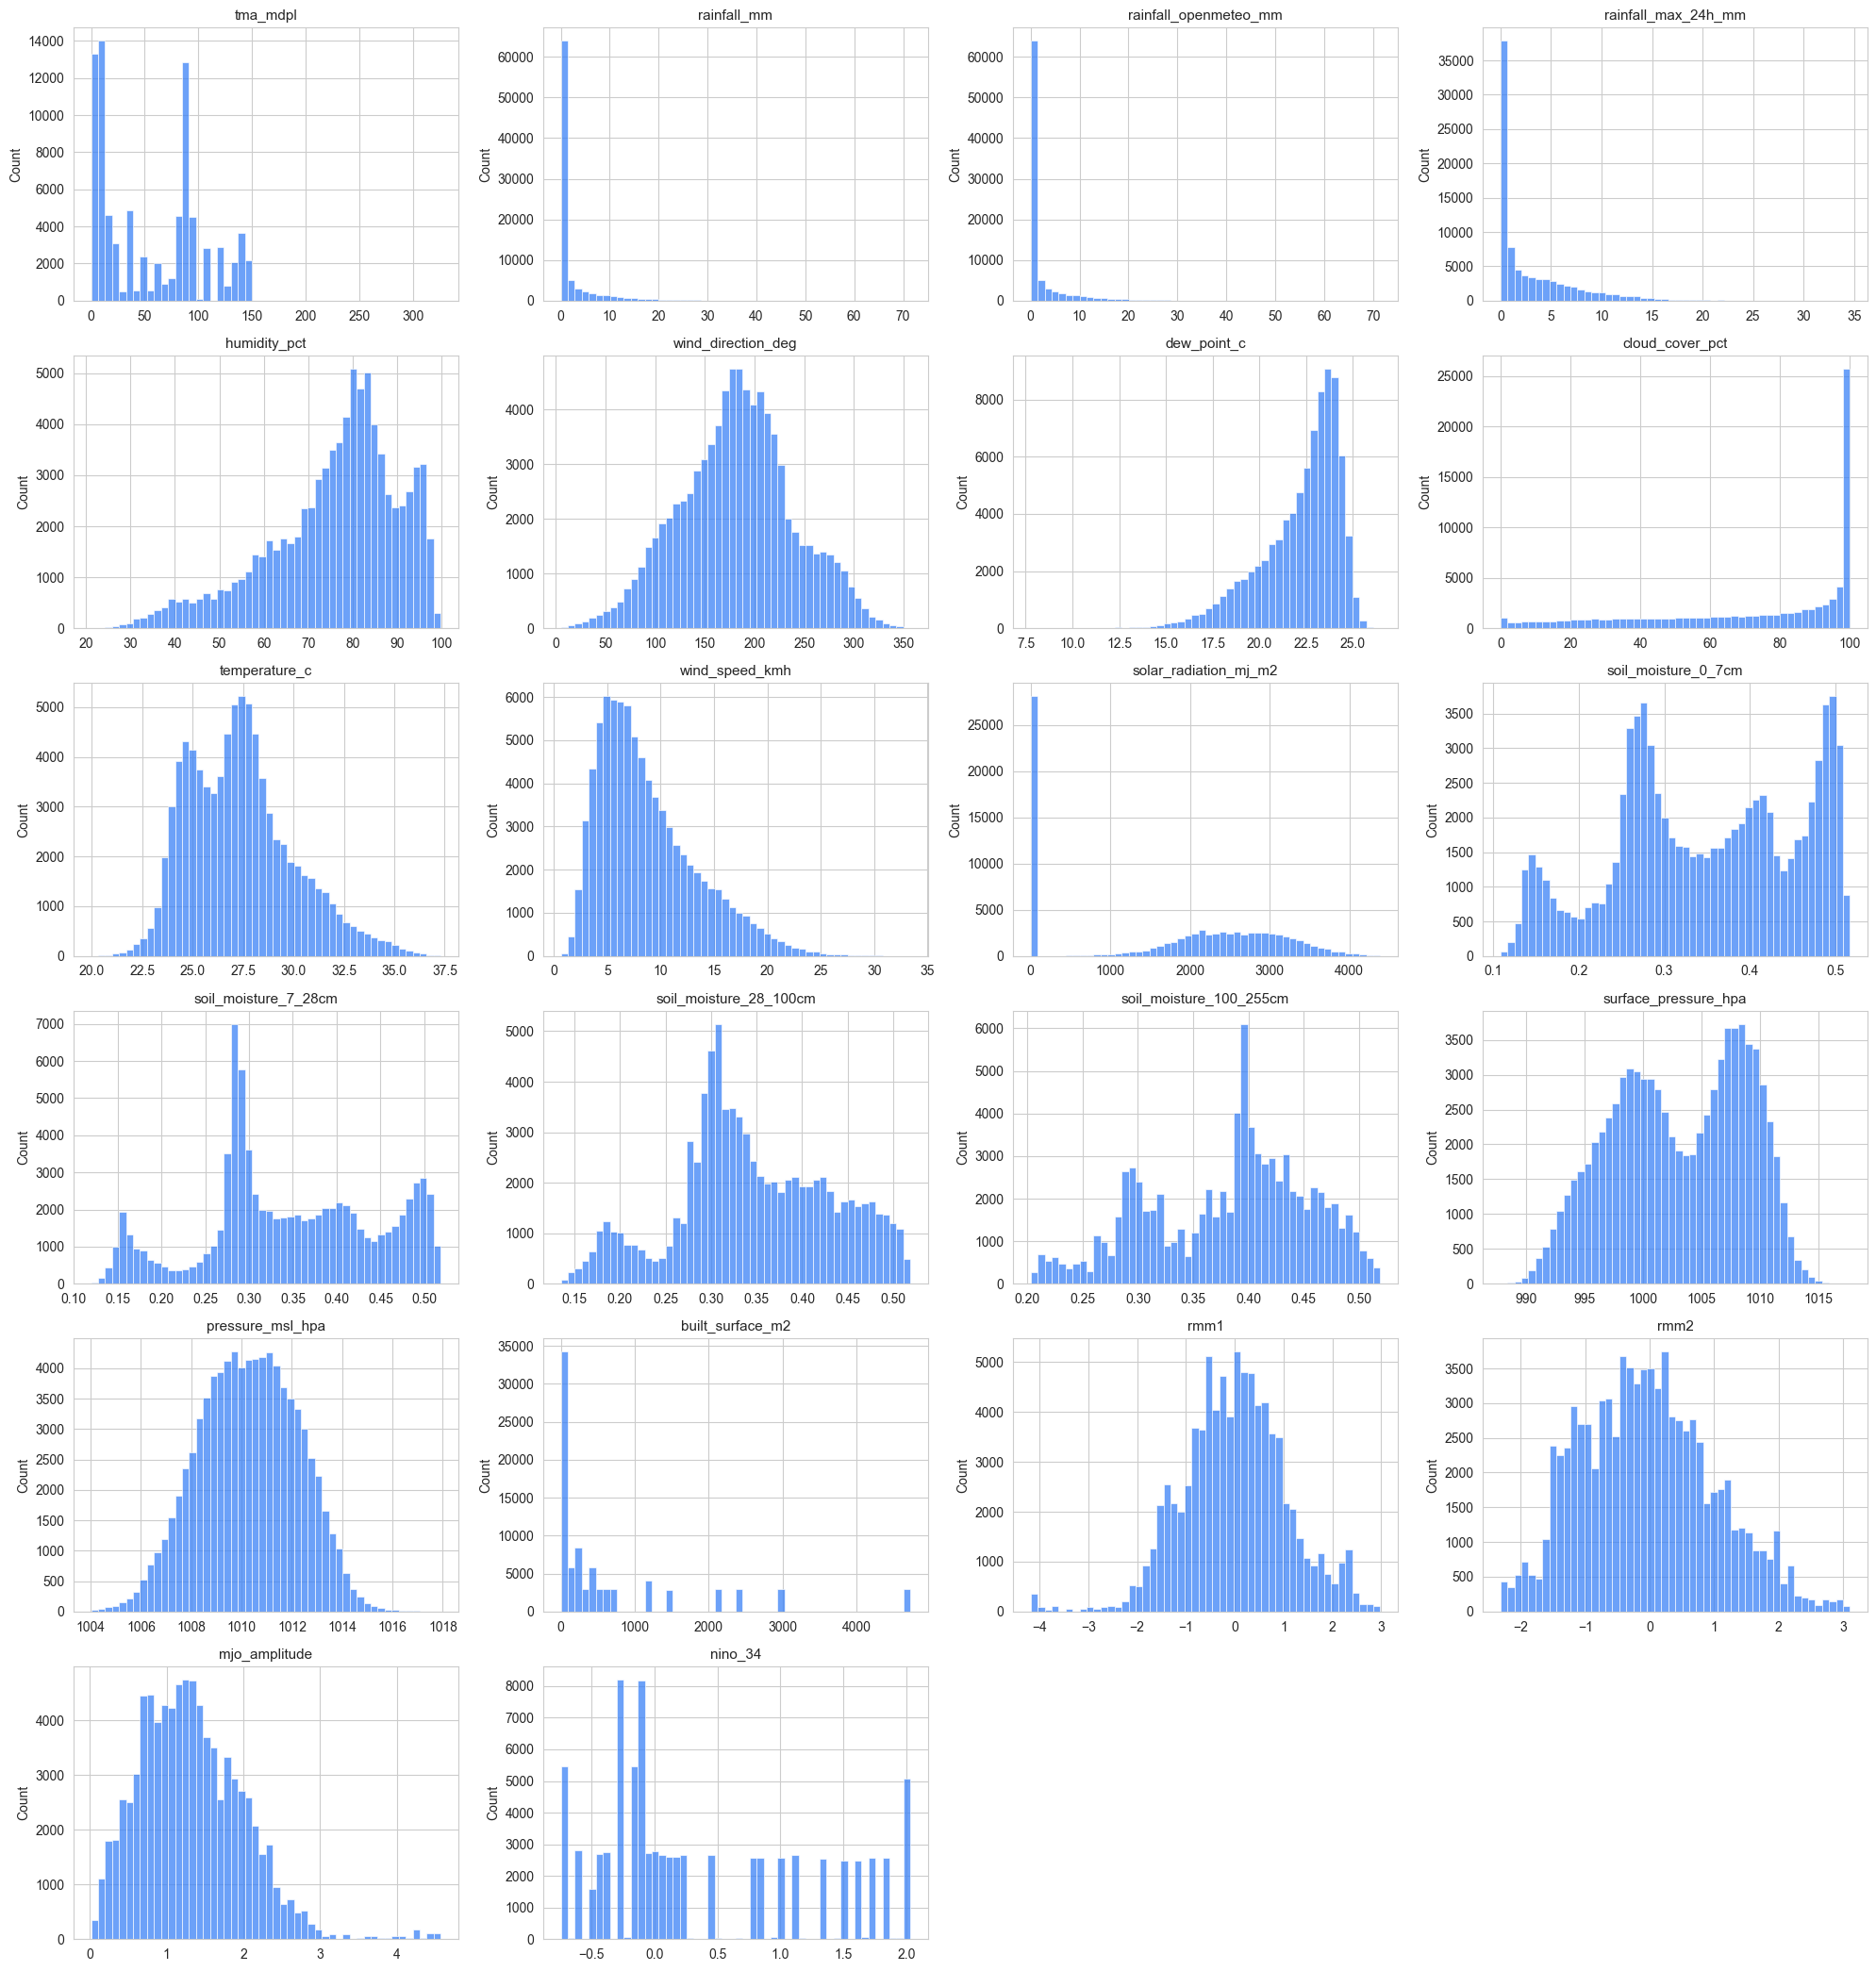

In [8]:
n_cols = 4
n_rows = int(np.ceil(len(feature_cols)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*3.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(train[col].dropna(), bins=50, color='#3b82f6', ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

for j in range(len(feature_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

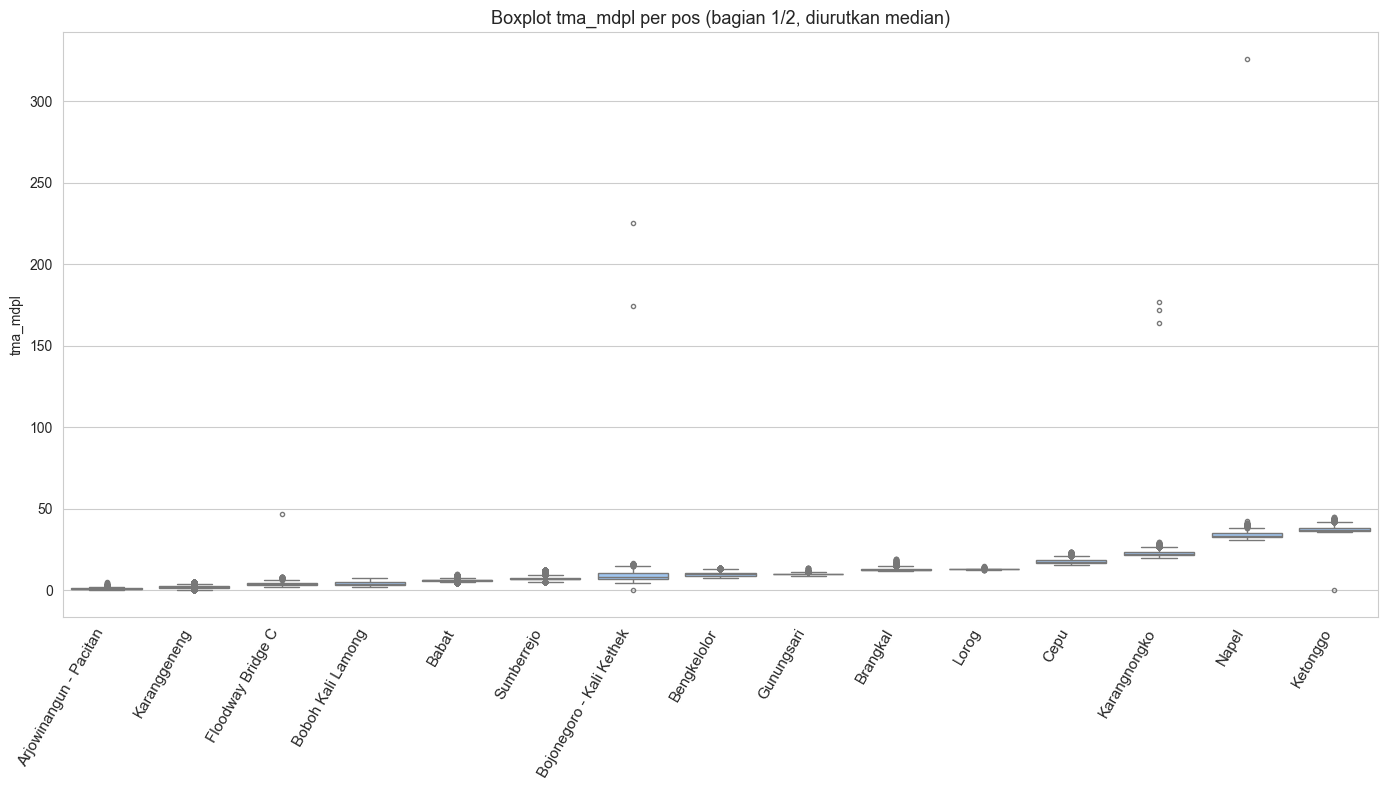

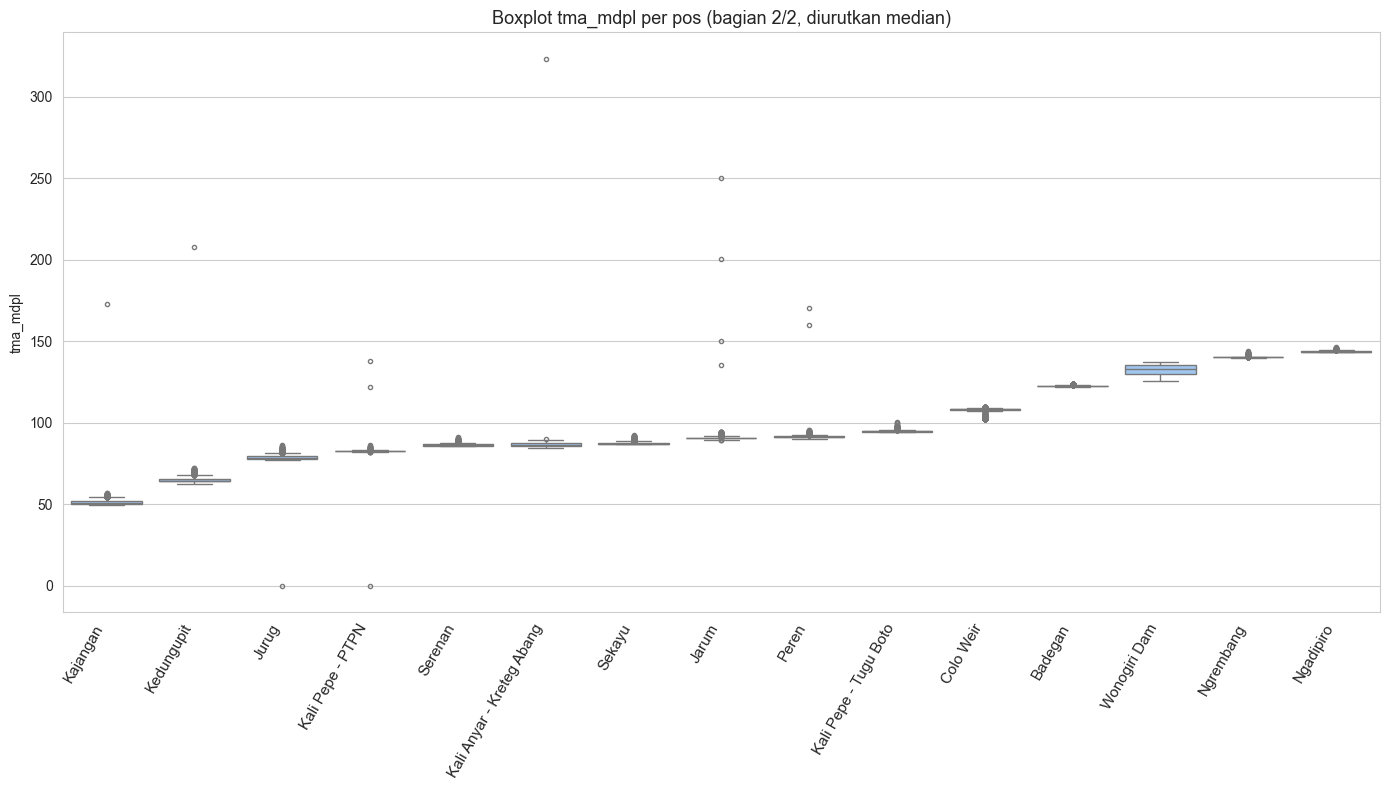

In [9]:
order = train.groupby('nama_pos')['tma_mdpl'].median().sort_values().index
half = len(order)//2
groups = [order[:half], order[half:]]

for idx, grp in enumerate(groups, start=1):
    fig, ax = plt.subplots(figsize=(14,8))
    sns.boxplot(data=train[train['nama_pos'].isin(grp)], x='nama_pos', y='tma_mdpl',
                order=grp, color='#93c5fd', fliersize=3, ax=ax)
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp, rotation=60, ha='right', fontsize=11)
    ax.set_title(f'Boxplot tma_mdpl per pos (bagian {idx}/2, diurutkan median)', fontsize=13)
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

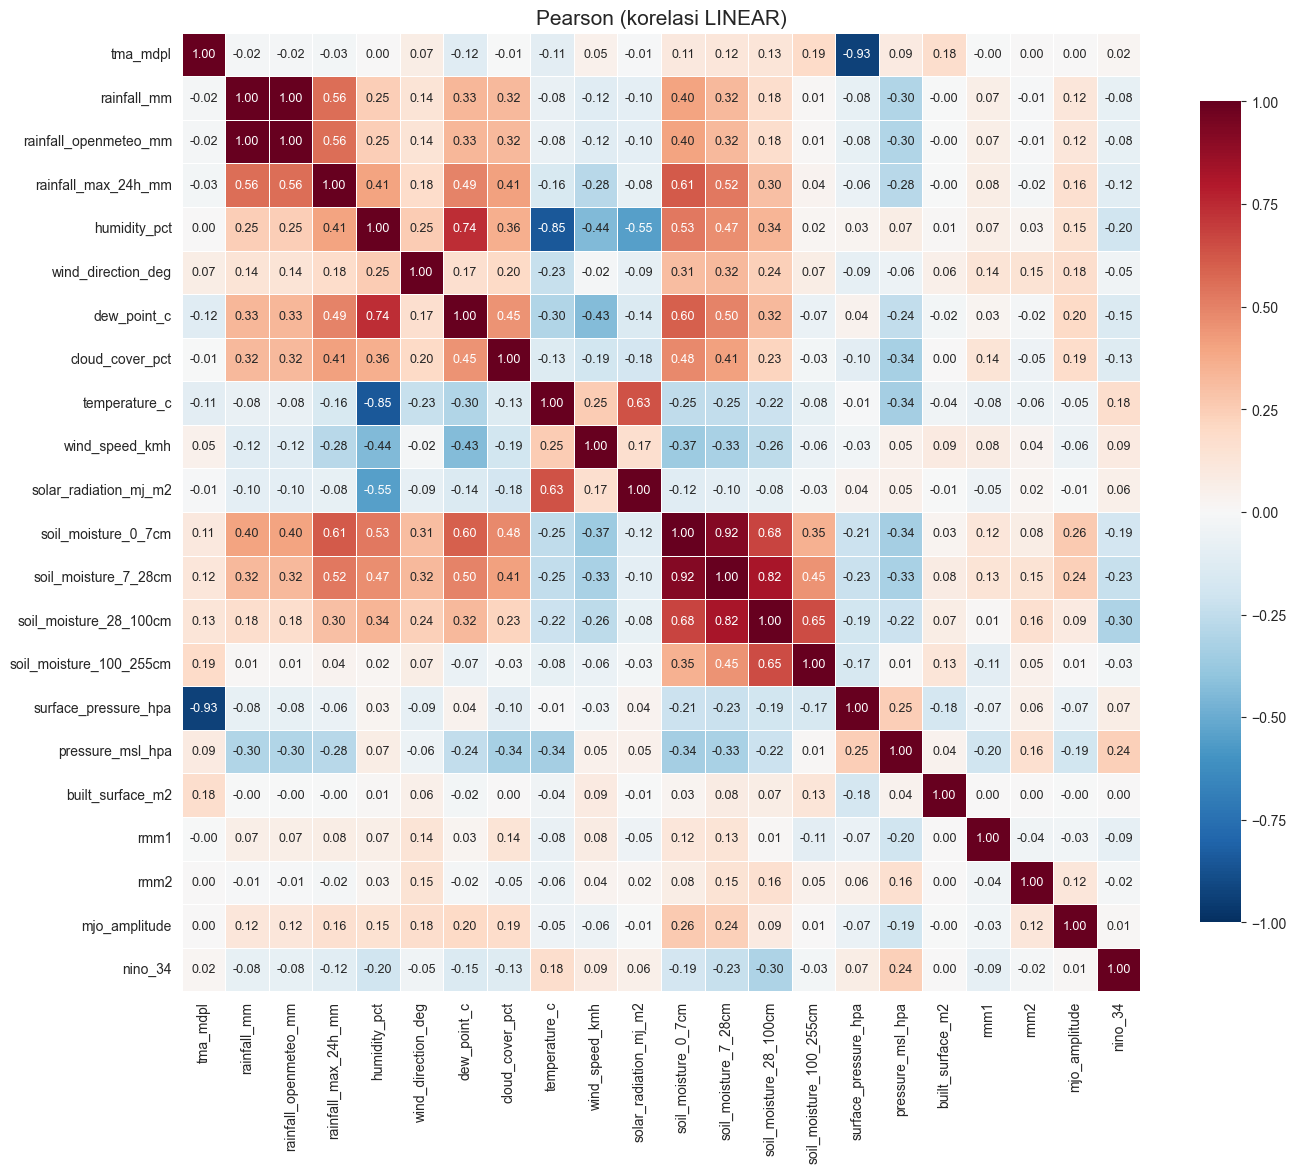

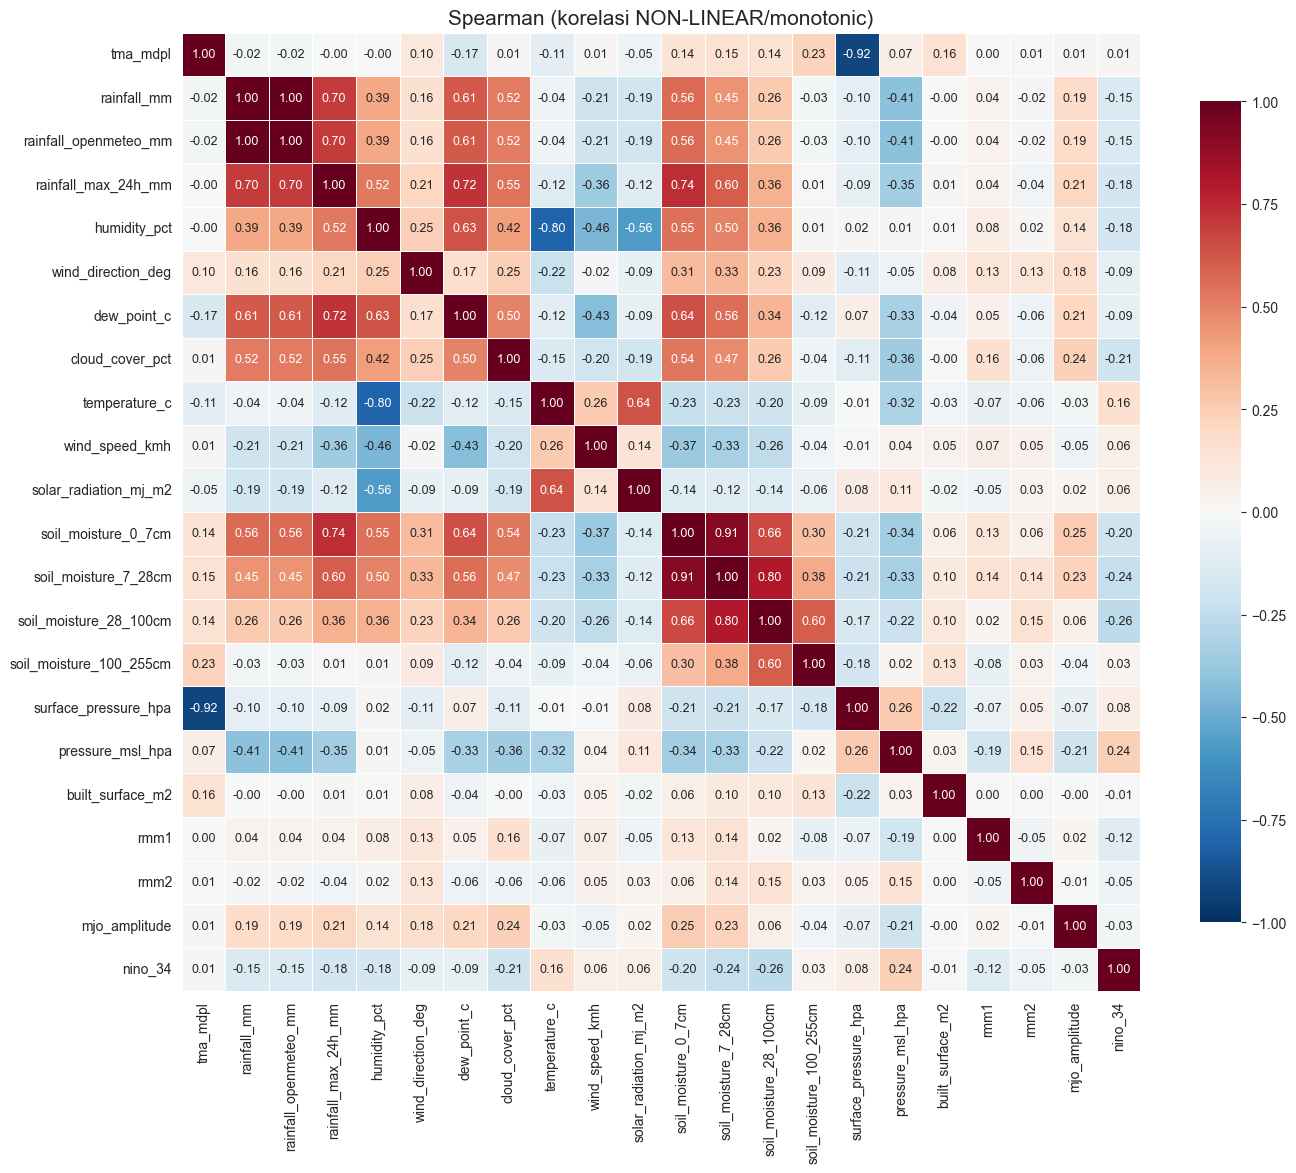

In [10]:
corr_pearson = train[feature_cols].corr(method='pearson')
corr_spearman = train[feature_cols].corr(method='spearman')

for corr, title in [(corr_pearson, 'Pearson (korelasi LINEAR)'),
                     (corr_spearman, 'Spearman (korelasi NON-LINEAR/monotonic)')]:
    fig, ax = plt.subplots(figsize=(14,12))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
                annot_kws={'size':9}, ax=ax, square=True, linewidths=0.5,
                cbar_kws={'shrink':0.8})
    ax.set_title(title, fontsize=15)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Preprocessing

## cek missing

In [11]:
print(train.isnull().sum())

datetime                       0
nama_pos                       0
tma_mdpl                       0
is_train                       0
id                         84396
rainfall_mm                    0
rainfall_openmeteo_mm          0
rainfall_max_24h_mm            0
humidity_pct                   0
wind_direction_deg             0
dew_point_c                    0
cloud_cover_pct                0
temperature_c                  0
wind_speed_kmh                 0
solar_radiation_mj_m2          0
soil_moisture_0_7cm            0
soil_moisture_7_28cm           0
soil_moisture_28_100cm         0
soil_moisture_100_255cm        0
surface_pressure_hpa           0
pressure_msl_hpa               0
built_surface_m2               0
landcover_class                0
landcover_name                 0
rmm1                           0
rmm2                           0
mjo_phase                      0
mjo_amplitude                  0
mjo_active                     0
nino_34                        0
dtype: int

## feature engineering

### check dataset gabungan

In [12]:
full.head()

,datetime,nama_pos,tma_mdpl,is_train,id,rainfall_mm,rainfall_openmeteo_mm,rainfall_max_24h_mm,humidity_pct,wind_direction_deg,...,pressure_msl_hpa,built_surface_m2,landcover_class,landcover_name,rmm1,rmm2,mjo_phase,mjo_amplitude,mjo_active,nino_34
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30,1,NaN,0.0,0.0,0.0,86.000000,348.333333,...,1009.066667,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20,1,NaN,0.3,0.3,0.2,79.166667,327.666667,...,1010.800000,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50,1,NaN,3.6,3.6,1.7,81.666667,296.333333,...,1008.983333,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45,1,NaN,1.0,1.0,1.7,90.250000,316.166667,...,1010.000000,2419.0,10,Tree cover,-0.311643,1.335574,7.0,1.386106,1.0,-0.72
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25,1,NaN,0.6,0.6,1.7,79.500000,298.166667,...,1010.766667,2419.0,10,Tree cover,-0.530987,1.393549,7.0,1.491283,1.0,-0.72


### dropping Columns

In [13]:


full.drop([
    "rainfall_openmeteo_mm", # korelasi = 1
], axis=1, inplace=True)

### adding features

In [15]:
full = pd.read_csv('data/full_data_merged.csv', parse_dates=['datetime'])
koor = pd.read_csv('data/data_pendukung/koordinat_pos.csv')

full.drop(['rainfall_openmeteo_mm'], axis=1, inplace=True)
full = full.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# ===== reindex grid 6-jaman (msh perlu, krn rain/soil_moisture lag-roll butuh alignment waktu) =====
grids = []
for pos, g in full.groupby('nama_pos'):
    full_range = pd.date_range(g['datetime'].min(), g['datetime'].max(), freq='6h')
    full_range = full_range[full_range.hour.isin([6,12,18])]
    grids.append(pd.DataFrame({'nama_pos': pos, 'datetime': full_range}))
grid = pd.concat(grids, ignore_index=True)
full = grid.merge(full, on=['nama_pos','datetime'], how='left')
full['is_phantom'] = full['is_train'].isna().astype(int)
full = full.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# ===== FITUR WAKTU (lebih lengkap) =====
full['hour'] = full['datetime'].dt.hour
full['day'] = full['datetime'].dt.day
full['month'] = full['datetime'].dt.month
full['week'] = full['datetime'].dt.isocalendar().week.astype(int)
full['quarter'] = full['datetime'].dt.quarter
full['dayofyear'] = full['datetime'].dt.dayofyear
full['dayofweek'] = full['datetime'].dt.dayofweek
full['is_weekend'] = full['dayofweek'].isin([5,6]).astype(int)
full['hour_sin'] = np.sin(2*np.pi*full['hour']/24)
full['hour_cos'] = np.cos(2*np.pi*full['hour']/24)
full['month_sin'] = np.sin(2*np.pi*full['month']/12)
full['month_cos'] = np.cos(2*np.pi*full['month']/12)
full['dayofyear_sin'] = np.sin(2*np.pi*full['dayofyear']/365)
full['dayofyear_cos'] = np.cos(2*np.pi*full['dayofyear']/365)

# ===== FITUR CUACA: lag & rolling (SEMUA berbasis cuaca, BUKAN target -> gak butuh recursion) =====
g = full.groupby('nama_pos')

def rollsum(col, n): return g[col].transform(lambda x: x.shift(1).rolling(n).sum())
def rollmean(col, n): return g[col].transform(lambda x: x.shift(1).rolling(n).mean())

full['rainfall_mm_lag_1'] = g['rainfall_mm'].shift(1)
full['rainfall_mm_lag_3'] = g['rainfall_mm'].shift(3)
full['rainfall_mm_lag_6'] = g['rainfall_mm'].shift(6)
full['humidity_lag_1'] = g['humidity_pct'].shift(1)
full['soil_moisture_0_7cm_lag_1'] = g['soil_moisture_0_7cm'].shift(1)
full['soil_moisture_7_28cm_lag_1'] = g['soil_moisture_7_28cm'].shift(1)
full['soil_moisture_28_100cm_lag_1'] = g['soil_moisture_28_100cm'].shift(1)
full['soil_moisture_100_255cm_lag_1'] = g['soil_moisture_100_255cm'].shift(1)

full['rainfall_mm_roll_sum_6'] = rollsum('rainfall_mm', 6)
full['rainfall_mm_roll_sum_12'] = rollsum('rainfall_mm', 12)
full['soil_moisture_0_7cm_roll_mean_6'] = rollmean('soil_moisture_0_7cm', 6)
full['soil_moisture_7_28cm_roll_mean_6'] = rollmean('soil_moisture_7_28cm', 6)
full['soil_moisture_28_100cm_roll_mean_6'] = rollmean('soil_moisture_28_100cm', 6)
full['soil_moisture_100_255cm_roll_mean_6'] = rollmean('soil_moisture_100_255cm', 6)

# akumulasi hujan multi-window (48h=8 periode, 96h=16, 144h=24, 168h=28, 336h=56 -- satuan 6 jam-an)
full['rain_cumsum_48h']  = rollsum('rainfall_mm', 8)
full['rain_cumsum_96h']  = rollsum('rainfall_mm', 16)
full['rain_cumsum_144h'] = rollsum('rainfall_mm', 24)
full['rain_cumsum_168h'] = rollsum('rainfall_mm', 28)
full['rain_cumsum_336h'] = rollsum('rainfall_mm', 56)

# indeks iklim: rolling mean jangka panjang (120 & 240 periode 6-jaman = ~30 & ~60 hari)
for col in ['rmm1','rmm2','mjo_amplitude','nino_34']:
    full[f'{col}_roll_mean_120'] = rollmean(col, 120)
    full[f'{col}_roll_mean_240'] = rollmean(col, 240)

full['delta_rain_1'] = g['rainfall_mm'].diff(1)
full['delta_pressure_1'] = g['surface_pressure_hpa'].diff(1)

full['wind_dir_sin'] = np.sin(np.radians(full['wind_direction_deg']))
full['wind_dir_cos'] = np.cos(np.radians(full['wind_direction_deg']))

# ===== buang phantom, gabung lokasi =====
full = full[full['is_phantom']==0].drop(columns=['is_phantom']).reset_index(drop=True)
full = full.merge(koor, on='nama_pos', how='left')

# ===== FITUR STASIUN STATIS (KUNCI: gantikan tma_lag tanpa butuh recursion) =====
train_mask = full['is_train']==1
station_stats = full[train_mask].groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
full = full.merge(station_stats, on='nama_pos', how='left')

# ===== nearest_station_dist (haversine, dari koordinat) =====
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

pos_coords = koor.set_index('nama_pos')[['latitude','longitude']]
nearest_dist = {p1: min(haversine(*pos_coords.loc[p1], *pos_coords.loc[p2])
                          for p2 in pos_coords.index if p2 != p1)
                 for p1 in pos_coords.index}
full['nearest_station_dist'] = full['nama_pos'].map(nearest_dist)

# ===== encoding kategorikal =====
from sklearn.preprocessing import LabelEncoder
for col in ['nama_pos','landcover_name','mjo_phase','mjo_active']:
    le = LabelEncoder()
    full[col+'_enc'] = le.fit_transform(full[col].astype(str))

train = full[full['is_train']==1].copy()
test = full[full['is_train']==0].copy()
non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']
feature_cols = [c for c in train.columns if c not in non_feature]
print(train.shape, test.shape, len(feature_cols), 'fitur')

(84396, 84) (21780, 84) 76 fitur


## finalize before split train and val

balikin train ke train dan test ke test dari full, remove non feature columns

In [17]:
train = full[full['is_train']==1].copy() # balikin train ke train
test = full[full['is_train']==0].copy() # balikin test ke test

non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active'] # remove non feature column
feature_cols = [c for c in train.columns if c not in non_feature] 
print(train.shape, test.shape, len(feature_cols), 'fitur')

(84396, 84) (21780, 84) 76 fitur


In [18]:
train.head()

,nama_pos,datetime,tma_mdpl,is_train,id,rainfall_mm,rainfall_max_24h_mm,humidity_pct,wind_direction_deg,dew_point_c,...,latitude,longitude,station_mean_tma,station_min_tma,station_max_tma,nearest_station_dist,nama_pos_enc,landcover_name_enc,mjo_phase_enc,mjo_active_enc
0,Arjowinangun - Pacitan,2023-01-01 06:00:00,1.30,1.0,NaN,0.0,0.0,86.000000,348.333333,22.466667,...,-8.197561,111.114314,1.116478,0.347639,4.85,7.188337,0,3,6,1
1,Arjowinangun - Pacitan,2023-01-01 12:00:00,1.20,1.0,NaN,0.3,0.2,79.166667,327.666667,23.550000,...,-8.197561,111.114314,1.116478,0.347639,4.85,7.188337,0,3,6,1
2,Arjowinangun - Pacitan,2023-01-01 18:00:00,1.50,1.0,NaN,3.6,1.7,81.666667,296.333333,24.050000,...,-8.197561,111.114314,1.116478,0.347639,4.85,7.188337,0,3,6,1
3,Arjowinangun - Pacitan,2023-01-02 06:00:00,1.45,1.0,NaN,1.0,1.7,90.250000,316.166667,23.316667,...,-8.197561,111.114314,1.116478,0.347639,4.85,7.188337,0,3,6,1
4,Arjowinangun - Pacitan,2023-01-02 12:00:00,1.25,1.0,NaN,0.6,1.7,79.500000,298.166667,23.333333,...,-8.197561,111.114314,1.116478,0.347639,4.85,7.188337,0,3,6,1


## split data train val

In [19]:
cutoff = pd.Timestamp('2025-03-03')  # ~80% waktu pertama utk train, 20% terakhir utk val

train_set = train[train['datetime'] < cutoff].copy()
val_set = train[train['datetime'] >= cutoff].copy()

print(train_set.shape, val_set.shape)
print('train_set:', train_set['datetime'].min(), '-', train_set['datetime'].max())
print('val_set:', val_set['datetime'].min(), '-', val_set['datetime'].max())
# pastikan semua 30 pos ada di kedua set
print('pos di train_set:', train_set['nama_pos'].nunique(), '| pos di val_set:', val_set['nama_pos'].nunique())

(66441, 84) (17955, 84)
train_set: 2023-01-01 06:00:00 - 2025-03-02 18:00:00
val_set: 2025-03-03 06:00:00 - 2025-09-18 18:00:00
pos di train_set: 30 | pos di val_set: 30


### versi without lag/roll

In [20]:
lagroll_cols = [
    'tma_lag_1', 'tma_lag_2', 'tma_lag_4', 'tma_lag_28',
    'tma_roll_mean_4', 'tma_roll_std_4',
    'tma_roll_mean_28', 'tma_roll_min_28', 'tma_roll_max_28',
    'tma_delta_1'
]

# Buat feature_cols tanpa lagroll untuk perbandingan model
feature_cols_no_lagroll = [c for c in feature_cols if c not in lagroll_cols]

# Modelling

## Train Recursive untuk lag/roll

In [21]:
def recursive_predict(model, train_hist_df, target_df, feature_cols):
    """
    Prediksi target_df (bisa val_set ATAU test) secara RECURSIVE.
    - Kolom lag yg ADA di feature_cols dihitung dari history (actual + prediksi sblmnya)
    - Kolom lag yg TIDAK dipakai model (spt tma_lag_1 kalau lagi eksperimen tanpa itu) otomatis di-skip
    """
    history = {}
    for pos, g in train_hist_df.sort_values('datetime').groupby('nama_pos'):
        history[pos] = list(g['tma_mdpl'].tail(28).values)

    target_df = target_df.sort_values(['datetime','nama_pos']).reset_index(drop=True)
    timestamps = sorted(target_df['datetime'].unique())
    predictions = {}

    for t in timestamps:
        rows = target_df[target_df['datetime']==t].set_index('nama_pos').copy()
        pos_present = rows.index.tolist()
        for pos in pos_present:
            h = history[pos]
            if 'tma_lag_1' in feature_cols:  rows.loc[pos,'tma_lag_1']=h[-1]
            if 'tma_lag_2' in feature_cols:  rows.loc[pos,'tma_lag_2']=h[-2]
            if 'tma_lag_4' in feature_cols:  rows.loc[pos,'tma_lag_4']=h[-4]
            if 'tma_lag_28' in feature_cols: rows.loc[pos,'tma_lag_28']=h[-28]
            if 'tma_roll_mean_4' in feature_cols:  rows.loc[pos,'tma_roll_mean_4']=np.mean(h[-4:])
            if 'tma_roll_std_4' in feature_cols:   rows.loc[pos,'tma_roll_std_4']=np.std(h[-4:])
            if 'tma_roll_mean_28' in feature_cols: rows.loc[pos,'tma_roll_mean_28']=np.mean(h[-28:])
            if 'tma_roll_min_28' in feature_cols:  rows.loc[pos,'tma_roll_min_28']=np.min(h[-28:])
            if 'tma_roll_max_28' in feature_cols:  rows.loc[pos,'tma_roll_max_28']=np.max(h[-28:])
            if 'tma_delta_1' in feature_cols:      rows.loc[pos,'tma_delta_1']=h[-1]-h[-2]
        X_t = rows[feature_cols]
        y_pred_t = model.predict(X_t)
        for pos, pred in zip(pos_present, y_pred_t):
            history[pos].append(pred)
            predictions[(t,pos)] = pred

    target_df['pred'] = target_df.apply(lambda r: predictions[(r['datetime'], r['nama_pos'])], axis=1)
    return target_df

In [22]:
short_lag_cols = ['tma_lag_1', 'tma_lag_2', 'tma_delta_1']
feature_cols = [c for c in feature_cols if c not in short_lag_cols]

In [23]:
# LAGROLL (with short lags removed) - buat variable eksplisit
X_train = train_set[feature_cols]
y_train = train_set['tma_mdpl']
X_val = val_set[feature_cols]
y_val = val_set['tma_mdpl']

# NO LAGROLL - dibuat dari feature_cols_no_lagroll
X_train_no_lagroll = train_set[feature_cols_no_lagroll]
y_train_no_lagroll = train_set['tma_mdpl']
X_val_no_lagroll = val_set[feature_cols_no_lagroll]
y_val_no_lagroll = val_set['tma_mdpl']

In [24]:
non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']
feature_cols = [c for c in train.columns if c not in non_feature]

cutoff = pd.Timestamp('2025-03-03')
train_set = train[train['datetime'] < cutoff].copy()
val_set = train[train['datetime'] >= cutoff].copy()

cutoffs = [
    ('2024-09-01', '2025-03-03'),
    ('2024-12-01', '2025-06-01'),
    ('2025-03-03', '2025-09-18'),
]

xgb_params  = dict(n_estimators=84,  learning_rate=0.05, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8, random_state=42)
lgbm_params = dict(n_estimators=136, learning_rate=0.05, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
cat_params  = dict(iterations=216,  learning_rate=0.05, depth=6,
                    subsample=0.8, colsample_bylevel=0.8, random_state=42, verbose=False)

### XGBoost

In [25]:
xgb = XGBRegressor(**xgb_params)
xgb.fit(train_set[feature_cols], train_set['tma_mdpl'])

pred_val_xgb = xgb.predict(val_set[feature_cols])
rmse_xgb = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_xgb))
print(f'RMSE XGBoost (single split): {rmse_xgb:.4f}')

RMSE XGBoost (single split): 2.6027


In [26]:
results_xgb = []
for train_end, val_end in cutoffs:
    tr = train[train['datetime'] < train_end]
    va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]
    model = XGBRegressor(**xgb_params)
    model.fit(tr[feature_cols], tr['tma_mdpl'])
    pred = model.predict(va[feature_cols])
    rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
    results_xgb.append(rmse)
    print(f'Fold RMSE: {rmse:.4f}')
print(f'RMSE CV rata-rata: {np.mean(results_xgb):.4f} +/- {np.std(results_xgb):.4f}')

Fold RMSE: 2.7739
Fold RMSE: 2.4732
Fold RMSE: 2.6058
RMSE CV rata-rata: 2.6176 +/- 0.1231


## LGBM

In [27]:
lgbm = LGBMRegressor(**lgbm_params)
lgbm.fit(train_set[feature_cols], train_set['tma_mdpl'])

pred_val_lgbm = lgbm.predict(val_set[feature_cols])
rmse_lgbm = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_lgbm))
print(f'RMSE LightGBM (single split): {rmse_lgbm:.4f}')

RMSE LightGBM (single split): 1.1100


In [28]:
results_lgbm = []
for train_end, val_end in cutoffs:
    tr = train[train['datetime'] < train_end]
    va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]
    model = LGBMRegressor(**lgbm_params)
    model.fit(tr[feature_cols], tr['tma_mdpl'])
    pred = model.predict(va[feature_cols])
    rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
    results_lgbm.append(rmse)
    print(f'Fold RMSE: {rmse:.4f}')
print(f'RMSE CV rata-rata: {np.mean(results_lgbm):.4f} +/- {np.std(results_lgbm):.4f}')

Fold RMSE: 2.0284
Fold RMSE: 1.6124
Fold RMSE: 1.1111
RMSE CV rata-rata: 1.5840 +/- 0.3750


## CatBoost

In [29]:
cat = CatBoostRegressor(**cat_params)
cat.fit(train_set[feature_cols], train_set['tma_mdpl'])

pred_val_cat = cat.predict(val_set[feature_cols])
rmse_cat = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_cat))
print(f'RMSE CatBoost (single split): {rmse_cat:.4f}')

RMSE CatBoost (single split): 1.1379


In [30]:
results_cat = []
for train_end, val_end in cutoffs:
    tr = train[train['datetime'] < train_end]
    va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]
    model = CatBoostRegressor(**cat_params)
    model.fit(tr[feature_cols], tr['tma_mdpl'])
    pred = model.predict(va[feature_cols])
    rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
    results_cat.append(rmse)
    print(f'Fold RMSE: {rmse:.4f}')
print(f'RMSE CV rata-rata: {np.mean(results_cat):.4f} +/- {np.std(results_cat):.4f}')

Fold RMSE: 1.4282
Fold RMSE: 1.4981
Fold RMSE: 1.1381
RMSE CV rata-rata: 1.3548 +/- 0.1559


### Perbandingan XGB vs LGBM vs CatBoost

In [31]:
comparison = pd.DataFrame({
    'model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'RMSE_single_split': [rmse_xgb, rmse_lgbm, rmse_cat],
    'RMSE_CV_mean': [np.mean(results_xgb), np.mean(results_lgbm), np.mean(results_cat)],
    'RMSE_CV_std': [np.std(results_xgb), np.std(results_lgbm), np.std(results_cat)],
})
comparison['RMSE_CV_mean_pm_std'] = comparison.apply(
    lambda r: f"{r['RMSE_CV_mean']:.4f} ± {r['RMSE_CV_std']:.4f}", axis=1
)
comparison_display = comparison[['model','RMSE_single_split','RMSE_CV_mean_pm_std']].sort_values('RMSE_single_split')
print(comparison_display.to_string(index=False))
comparison_display

   model  RMSE_single_split RMSE_CV_mean_pm_std
LightGBM           1.110049     1.5840 ± 0.3750
CatBoost           1.137916     1.3548 ± 0.1559
 XGBoost           2.602704     2.6176 ± 0.1231


,model,RMSE_single_split,RMSE_CV_mean_pm_std
1,LightGBM,1.110049,1.5840 ± 0.3750
2,CatBoost,1.137916,1.3548 ± 0.1559
0,XGBoost,2.602704,2.6176 ± 0.1231


# Submission

## XGB

### Lagroll

In [ ]:
# retrain model final pakai SEMUA train, fitur v2, n_estimators fixed (bukan early stopping bocor lagi)
xgb_final = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_final.fit(train[feature_cols], train['tma_mdpl'])

# function SAMA PERSIS, tinggal ganti target_df jadi test
test_result = recursive_predict(xgb_final, train, test.copy(), feature_cols)

submit_xgb = pd.DataFrame({
    'id': test_result['id'],
    'tma_mdpl': test_result['pred']
})
submit_xgb.to_csv('outputs/submission_xgb.csv', index=False)

## LGBM

In [ ]:
test_pred = lgbm.predict(test[feature_cols])

submit_lgbm = pd.DataFrame({'id': test['id'], 'tma_mdpl': test_pred})
submit_lgbm.to_csv('outputs/submission_lgbm_v2.csv', index=False)

## CatBoost

In [ ]:
cat_final = CatBoostRegressor(iterations=407, learning_rate=0.05, depth=6,
                                subsample=0.8, colsample_bylevel=0.8, random_state=42, verbose=False)
cat_final.fit(train[feature_cols], train['tma_mdpl'])

test_result = recursive_predict(cat_final, train, test.copy(), feature_cols)
submit_cat = pd.DataFrame({'id': test_result['id'], 'tma_mdpl': test_result['pred']})
submit_cat.to_csv('outputs/submission_catboost.csv', index=False)